In [1]:
import os
import json
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.legend_handler import HandlerTuple

from src.config import MODEL_CLASSES
import src.api.result as result_api


RESULTS_DIR = os.path.join("results")

# Shuffle

In [20]:
def load_results_prob(model_name, component):
    fname = f"{model_name}_symbol_20_shuffle_{component}.json"
    result_path = os.path.join(RESULTS_DIR, fname)
    with open(result_path, "r") as f:
        results = json.load(f)

    results = [result_api.ICLResult(**r) for r in results]
    
    # Initialize dictionary to store probabilities
    prob_dict = {
        "original": [],
        "inside": {str(i): [] for i in [0, 20, 40, 60, 80]},
        "outside": {str(i): [] for i in [0, 20, 40, 60, 80]}
    }
    
    for r in results:
        # Extract probabilities for each example
        example_probs = []
        for ex in r.examples:
            expected = ex["expected_answer"]
            # Get log prob for the expected answer
            log_prob = ex["multiple_choice_logprob"].get(f" {expected},", float('-inf'))
            # Convert to probability
            prob = np.exp(log_prob)
            example_probs.append(prob)
            
        # Store in appropriate category
        if "shuffle_meta" in r.model_details:
            shuffle_meta = r.model_details["shuffle_meta"]
            shuffle_type = shuffle_meta["shuffled_type"]
            shuffle_seed = str(shuffle_meta["seed"])
            prob_dict[shuffle_type][shuffle_seed] = np.mean(example_probs)
        else:
            prob_dict["original"] = np.mean(example_probs)
            
    return prob_dict


def load_results_acc(model_name, component):
    fname = f"{model_name}_symbol_20_shuffle_{component}.json"
    result_path = os.path.join(RESULTS_DIR, fname)
    with open(result_path, "r") as f:
        results = json.load(f)

    results = [result_api.ICLResult(**r) for r in results]

    # Initialize dictionary to store probabilities
    acc_dict = {
        "original": [],
        "inside": {str(i): [] for i in [0, 20, 40, 60, 80]},
        "outside": {str(i): [] for i in [0, 20, 40, 60, 80]}
    }
    
    for r in results:
        if "shuffle_meta" in r.model_details:
            shuffle_meta = r.model_details["shuffle_meta"]
            shuffle_type = shuffle_meta["shuffled_type"]
            shuffle_seed = str(shuffle_meta["seed"])
            acc_dict[shuffle_type][shuffle_seed] = r.accuracy
        else:
            acc_dict["original"] = r.accuracy
            
    return acc_dict

prob_qk = {}
prob_ov = {}
acc_qk = {}
acc_ov = {}

for model_name in MODEL_CLASSES:
    prob_qk[model_name] = load_results_prob(model_name, "qk")
    prob_ov[model_name] = load_results_prob(model_name, "ov")
    acc_qk[model_name] = load_results_acc(model_name, "qk")
    acc_ov[model_name] = load_results_acc(model_name, "ov")


In [26]:
def plot_shuffle_results(d_qk, d_ov, seed, type):
    cmap = matplotlib.cm.get_cmap("brg")
    colors = [cmap(t) for t in np.linspace(0, 0.9, len(MODEL_CLASSES))]

    fig, ax = plt.subplots(1, 1, figsize=(4, 4))
    label_handle = []
    label_names = []
    for i, model_name in enumerate(sorted(MODEL_CLASSES.keys())):
        d_model = d_qk[model_name]
        mu_original = d_model["original"]
        mu_inside = d_model["inside"][str(seed)]
        mu_outside = d_model["outside"][str(seed)]
        p1 = ax.scatter(
            (mu_original - mu_inside) / mu_original,
            (mu_original - mu_outside) / mu_original,
            marker="+",
            color=colors[i],
            s=100,
            label=model_name + " qk",
        )

        d_model = d_ov[model_name]
        mu_original = d_model["original"]
        mu_inside = d_model["inside"][str(seed)]
        mu_outside = d_model["outside"][str(seed)]
        p2 = ax.scatter(
            (mu_original - mu_inside) / mu_original,
            (mu_original - mu_outside) / mu_original,
            marker="x",
            color=colors[i],
            s=100,
            label=model_name + " ov",
        )
        label_handle.append((p1, p2))
        label_names.append(model_name + " QK/OV")

    ax.set_xlim((0 - 0.1, 1))
    ax.set_ylim((0 - 0.1, 1))
    l = ax.legend(
        label_handle, label_names, handler_map={tuple: HandlerTuple(ndivide=None)}
    )
    title = f"Reduced prop of {type} under edited model"
    ax.set_title(title, weight="bold", fontsize=12)
    ax.set_xlabel("Shuffle heads within", weight="bold", fontsize=14)
    ax.set_ylabel("Shuffle heads outside", weight="bold", fontsize=14)
    plt.savefig(
        os.path.join(RESULTS_DIR, f"shuffle_summary_{type}_seed{seed}.png"), bbox_inches="tight"
    )
    plt.show()        

/tmp/ipykernel_2398846/676404370.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = matplotlib.cm.get_cmap("brg")


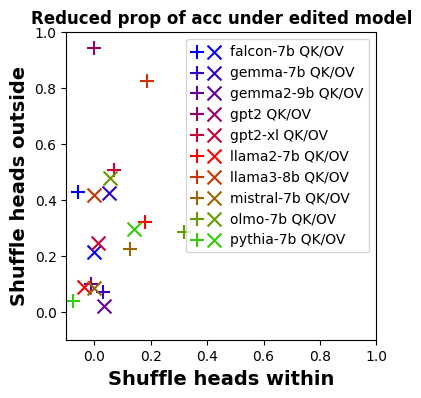

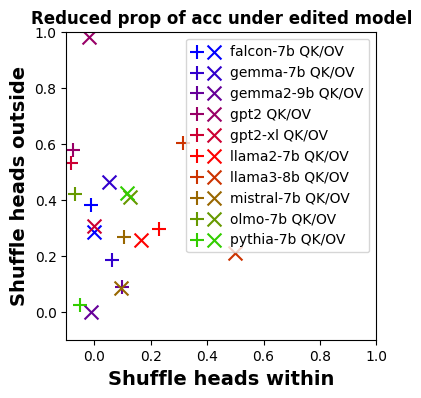

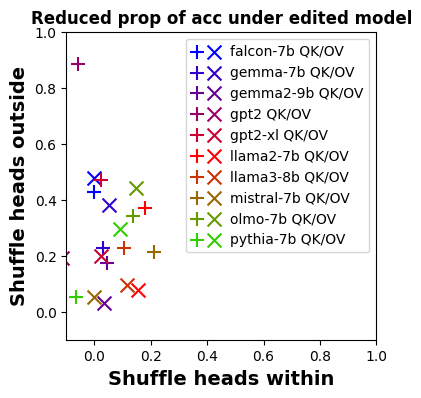

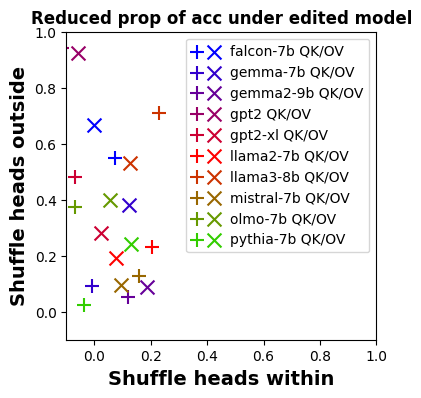

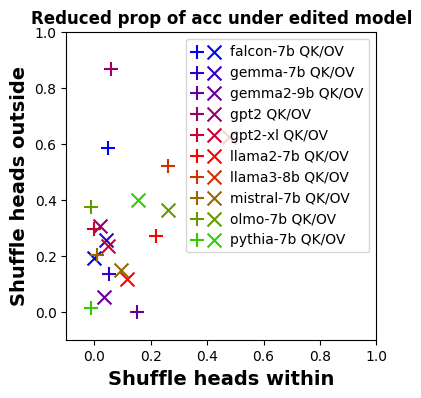

In [28]:
for seed in [0, 20, 40, 60, 80]:
    plot_shuffle_results(acc_qk, acc_ov, seed, "acc")

/tmp/ipykernel_2398846/676404370.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = matplotlib.cm.get_cmap("brg")


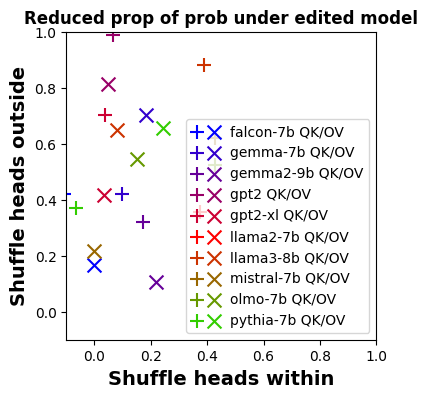

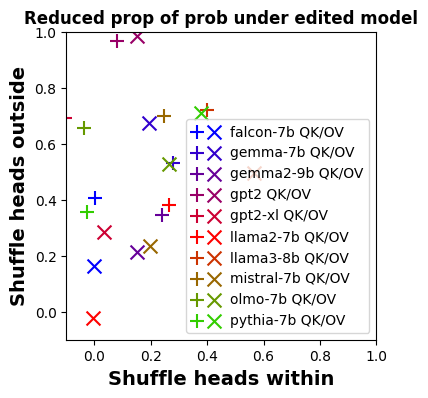

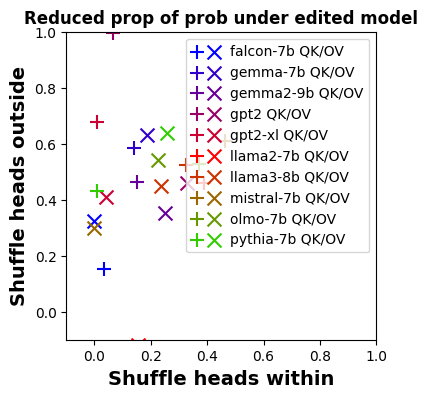

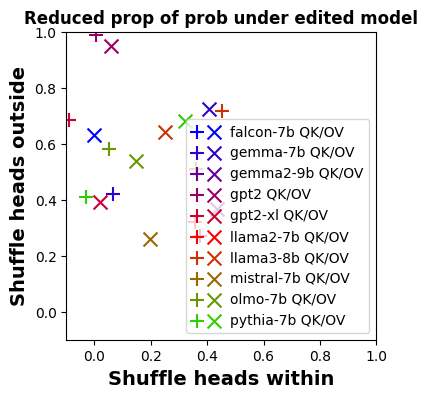

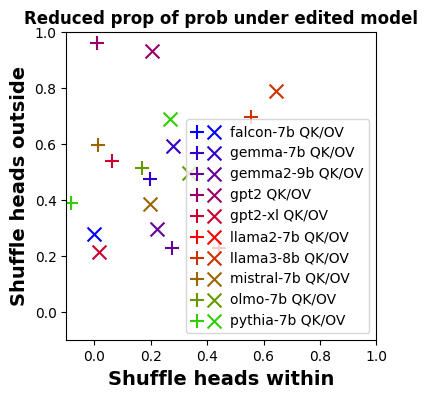

In [29]:
for seed in [0, 20, 40, 60, 80]:
    plot_shuffle_results(prob_qk, prob_ov, seed, "prob")

# Project

In [32]:
from src.evaluate_projection import ProjectionResult


def load_results_projection(model_name, component):
    fname = f"{model_name}_symbol_20_projection_{component}.json"
    result_path = os.path.join(RESULTS_DIR, fname)
    with open(result_path, "r") as f:
        results = json.load(f)

    results = [ProjectionResult(**r) for r in results]

    d_model = results[0].model_details["hidden_size"]
    K = max(50, int(0.05 * d_model / 10) * 10)
    
    rank = results[0].result["rank"]
    proj_true_acc = results[0].result["acc"]
    proj_false_acc = results[1].result["acc"]
    
    return {
        "original": proj_true_acc[0],
        "proj_true": proj_true_acc[rank.index(K)],
        "proj_false": proj_false_acc[rank.index(K)]
    }


def plot_projection_results(acc):
    import matplotlib
    from matplotlib.legend_handler import HandlerTuple

    cmap = matplotlib.cm.get_cmap("brg")
    colors = [cmap(t) for t in np.linspace(0, 0.9, len(MODEL_CLASSES))]

    fig, ax = plt.subplots(1, 1, figsize=(4, 4))
    label_handle = []
    label_names = []

    for i, model_name in enumerate(sorted(MODEL_CLASSES.keys())):
        acc_original = acc[model_name]["original"]
        acc_proj_true = acc[model_name]["proj_true"]
        acc_proj_false = acc[model_name]["proj_false"]
        p1 = ax.scatter(
            (acc_original - acc_proj_true) / acc_original,
            (acc_original - acc_proj_false) / acc_original,
            marker="+",
            s=100,
            color=colors[i],
        )
        label_handle.append((p1))
        label_names.append(model_name)

    ax.set_xlim((0 - 0.05, 1 + 0.05))
    ax.set_ylim((0 - 0.05, 1 + 0.05))
    l = ax.legend(
        label_handle, label_names, handler_map={tuple: HandlerTuple(ndivide=None)}
    )
    title = "Reduced prop of acc under edited model"
    ax.set_title(title, weight="bold", fontsize=13)
    ax.set_xlabel("Remove subspace", weight="bold", fontsize=14)
    ax.set_ylabel("Keep subspace", weight="bold", fontsize=14)
    plt.savefig(
        os.path.join(RESULTS_DIR, f"projection_summary_acc.png"), bbox_inches="tight"
    )
    plt.show()

/tmp/ipykernel_2398846/979030186.py:30: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = matplotlib.cm.get_cmap("brg")


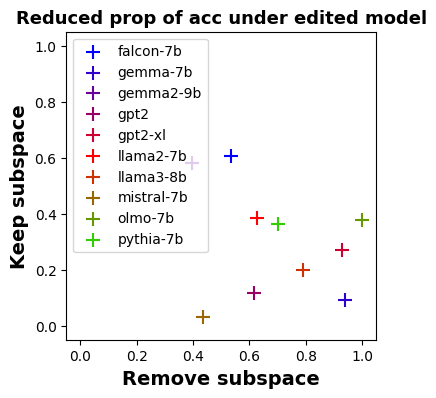

In [33]:
acc = {}
for model_name in MODEL_CLASSES:
    acc[model_name] = load_results_projection(model_name, "qk")

plot_projection_results(acc)